# IT Field Service Network Optimization Project

## 1. Introduction and Problem Definition
In modern IT field service operations, minimizing travel time between headquarters and branch locations is critical for maintaining SLA (Service Level Agreement) metrics and reducing operational costs. 

This project aims to optimize the emergency response routes for an IT Field Service team based in the **Fatih Headquarters**. The team needs to reach various districts across Istanbul (both European and Asian sides) using the most time-efficient routes. 


## 2. Mathematical Formulation

The shortest path problem can be formulated as a **0-1 Integer Linear Programming (ILP)** model. 

Let $X_{ij}$ be the decision variable:
* $X_{ij} = 1$, if the branch from node $i$ to node $j$ is selected as part of the shortest route.
* $X_{ij} = 0$, otherwise.

Let $C_{ij}$ be the weight (travel time in minutes) of the edge connecting node $i$ to node $j$.

**Objective Function:**
Our goal is to minimize the total travel time from the source node (Fatih) to a specific destination node (e.g., Atasehir).
$$
\begin{aligned}
Minimize \ Z = & \ 45X_{Fatih,Besiktas} + 35X_{Fatih,Kagithane} + 45X_{Fatih,Kadikoy} \\
& + 40X_{Fatih,Uskudar} + 20X_{Kadikoy,Uskudar} + 30X_{Kagithane,Besiktas} + 40X_{Besiktas,Uskudar} \\
& + 45X_{Besiktas,Umraniye} + 30X_{Uskudar,Umraniye} + 30X_{Uskudar,Atasehir} \\
& + 30X_{Kadikoy,Atasehir}
\end{aligned}
$$

**Subject to (Flow Conservation Constraints):**
Assuming we are finding the path from Fatih (Source) to Atasehir (Destination):

1. **Source Node (Fatih):** The net flow out must be 1.
$$X_{Fatih,Besiktas} + X_{Fatih,Kagithane} + X_{Fatih,Kadikoy} + X_{Fatih,Uskudar} = 1$$

2. **Intermediate Nodes (e.g., Kadikoy):** The flow in must equal the flow out (Net flow = 0).
$$X_{Fatih,Kadikoy} + X_{Uskudar,Kadikoy} - X_{Kadikoy,Atasehir} - X_{Kadikoy,Uskudar} = 0$$

3. **Destination Node (Atasehir):** The net flow in must be 1.
$$X_{Kadikoy,Atasehir} + X_{Umraniye,Atasehir} + X_{Uskudar,Atasehir} = 1$$

4. **Binary Constraint:**
$$X_{ij} \in \{0, 1\}$$

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the dataset from the parent directory
df = pd.read_csv("../data/network_data.csv")

# Display the first few rows to verify the data
print("Network Edges and Weights (Travel Time in Minutes):")
display(df)

Network Edges and Weights (Travel Time in Minutes):


,Source,Target,Weight
0,Fatih,Kagithane,35
1,Fatih,Besiktas,45
2,Kagithane,Besiktas,30
3,Besiktas,Uskudar,40
4,Fatih,Kadikoy,45
5,Fatih,Uskudar,40
6,Kadikoy,Uskudar,20
7,Besiktas,Umraniye,45
8,Uskudar,Umraniye,30
9,Uskudar,Atasehir,30


## 3. Network Construction & Optimization Model
To solve this ILP problem computationally, we utilize **Dijkstra's Algorithm** via the Python `NetworkX` library. The algorithm systematically evaluates the weights of interconnected nodes to find the optimal global minimum path from the headquarters to all other districts.

 IT FIELD SERVICE - OPTIMIZED ROUTING REPORT (HUB: FATIH)
Target: Kagithane  | Time: 35 mins | Route: Fatih -> Kagithane
Target: Uskudar    | Time: 40 mins | Route: Fatih -> Uskudar
Target: Besiktas   | Time: 45 mins | Route: Fatih -> Besiktas
Target: Kadikoy    | Time: 45 mins | Route: Fatih -> Kadikoy
Target: Umraniye   | Time: 70 mins | Route: Fatih -> Uskudar -> Umraniye
Target: Atasehir   | Time: 70 mins | Route: Fatih -> Uskudar -> Atasehir



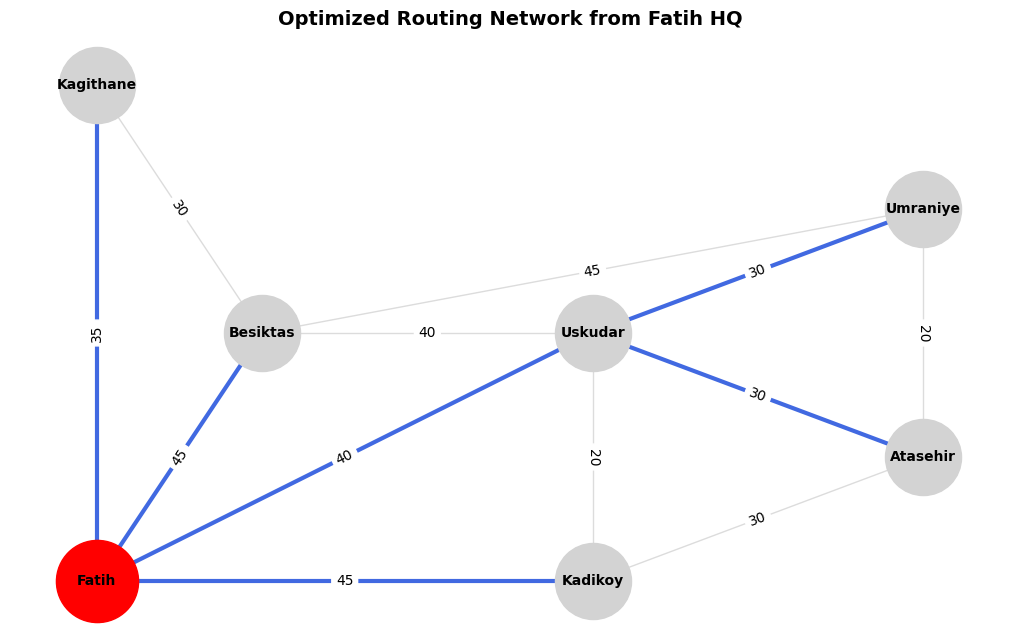

In [2]:
# Create the Graph
G = nx.Graph()
for index, row in df.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

source_node = "Fatih"

# Calculate shortest paths
lengths, paths = nx.single_source_dijkstra(G, source=source_node, weight='weight')

# Print the Managerial Report
print("="*65)
print(f" IT FIELD SERVICE - OPTIMIZED ROUTING REPORT (HUB: {source_node.upper()})")
print("="*65)

for target, time in sorted(lengths.items(), key=lambda x: x[1]):
    if target != source_node:
        route_str = " -> ".join(paths[target])
        print(f"Target: {target.ljust(10)} | Time: {str(time).rjust(2)} mins | Route: {route_str}")
print("="*65 + "\n")

# Custom Geographic Layout to prevent spaghetti effect
custom_pos = {
    "Kagithane": (-2, 3), "Besiktas": (-1, 1), "Fatih": (-2, -1),
    "Uskudar": (1, 1), "Kadikoy": (1, -1), "Umraniye": (3, 2), "Atasehir": (3, 0)
}

# Visualize the comprehensive optimized network
plt.figure(figsize=(10, 6))

# Highlight the core emergency network
used_edges = set()
for path in paths.values():
    for i in range(len(path)-1):
        used_edges.add(tuple(sorted((path[i], path[i+1]))))

nx.draw(G, custom_pos, with_labels=True, node_color='lightgray', node_size=3000, 
        font_size=10, font_weight='bold', edge_color='gainsboro')

nx.draw_networkx_nodes(G, custom_pos, nodelist=[source_node], node_color='red', node_size=3500)
nx.draw_networkx_edges(G, custom_pos, edgelist=list(used_edges), edge_color='royalblue', width=3.0)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, custom_pos, edge_labels=edge_labels, font_color='black')

plt.title(f"Optimized Routing Network from {source_node} HQ", fontsize=14, fontweight='bold')
plt.show() # Display the plot directly in the notebook

## 4. Scenario Analysis: Eurasia Tunnel Accident

In this scenario, we simulate a major traffic disruption in the Eurasia Tunnel. This event significantly increases travel times from the **Fatih Headquarters** to the **Kadikoy** and **Uskudar** nodes.

**Updated Weights for the Scenario:**
* Fatih -> Kadikoy: Increased from 40 to **90 mins**.
* Fatih -> Uskudar: Increased from 40 to **85 mins**.

 SCENARIO RESULTS: MAJOR ACCIDENT IMPACT (ALL ROUTES RECALCULATED)
Target: Kagithane  | New Time:  35 mins | Route: Fatih -> Kagithane
Target: Besiktas   | New Time:  45 mins | Route: Fatih -> Besiktas
Target: Uskudar    | New Time:  85 mins | Route: Fatih -> Besiktas -> Uskudar
Target: Umraniye   | New Time:  90 mins | Route: Fatih -> Besiktas -> Umraniye
Target: Kadikoy    | New Time: 105 mins | Route: Fatih -> Besiktas -> Uskudar -> Kadikoy
Target: Atasehir   | New Time: 110 mins | Route: Fatih -> Besiktas -> Umraniye -> Atasehir



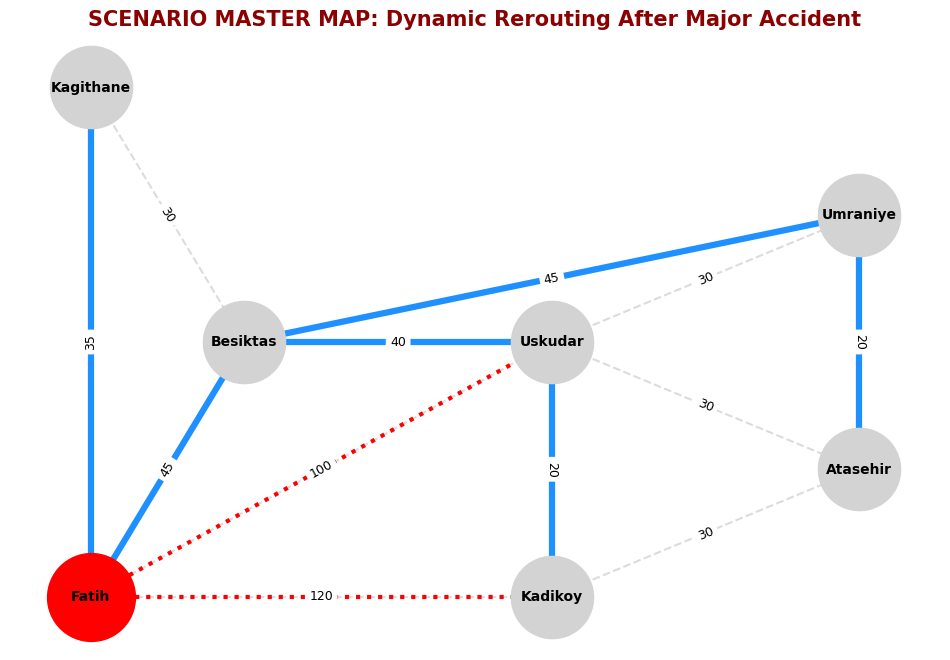

In [8]:
# 1. Create a copy of the graph to avoid modifying the original network
G_scenario = G.copy()

# 2. Scenario Update: Major accident! (Fatih->Kadikoy: 120 mins, Fatih->Uskudar: 100 mins)
G_scenario["Fatih"]["Kadikoy"]['weight'] = 120
G_scenario["Fatih"]["Uskudar"]['weight'] = 100

# 3. Recalculate all shortest paths with the new penalty weights
s_lengths, s_paths = nx.single_source_dijkstra(G_scenario, source="Fatih", weight='weight')

# 4. Print the Comprehensive Scenario Report
print("="*80)
print(" SCENARIO RESULTS: MAJOR ACCIDENT IMPACT (ALL ROUTES RECALCULATED)")
print("="*80)

for target, time in sorted(s_lengths.items(), key=lambda x: x[1]):
    if target != "Fatih":
        route_str = " -> ".join(s_paths[target])
        old_time = lengths[target] # Retrieve the original time for comparison
        print(f"Target: {target.ljust(10)} | New Time: {str(time).rjust(3)} mins | Route: {route_str}")
print("="*80 + "\n")

# 5. VISUALIZE ALL NEW ROUTES ON A SINGLE "MASTER" MAP
plt.figure(figsize=(12, 8))

# Identify all active edges used in the new shortest paths
used_edges = set()
for path in s_paths.values():
    for i in range(len(path)-1):
        used_edges.add(tuple(sorted((path[i], path[i+1]))))

# Define the edges affected by the accident
accident_edges = [tuple(sorted(("Fatih", "Kadikoy"))), tuple(sorted(("Fatih", "Uskudar")))]

# Draw all nodes in the network
nx.draw_networkx_nodes(G_scenario, custom_pos, node_color='lightgray', node_size=3500)
nx.draw_networkx_nodes(G_scenario, custom_pos, nodelist=["Fatih"], node_color='red', node_size=4000) # HQ Node

# 5.1. Draw all underlying edges lightly (as background)
nx.draw_networkx_edges(G_scenario, custom_pos, edge_color='gainsboro', style='dashed', width=1.5)

# 5.2. Highlight affected roads in RED and DOTTED (the bottlenecks)
nx.draw_networkx_edges(G_scenario, custom_pos, edgelist=accident_edges, edge_color='red', style='dotted', width=3.0)

# 5.3. Highlight the NEW ACTIVE ROUTES (Shortest Path Tree) in THICK BLUE
nx.draw_networkx_edges(G_scenario, custom_pos, edgelist=list(used_edges), edge_color='dodgerblue', width=4.5)

# Add node labels
nx.draw_networkx_labels(G_scenario, custom_pos, font_size=10, font_weight='bold')

# Add weight labels to the edges
edge_labels = nx.get_edge_attributes(G_scenario, 'weight')
nx.draw_networkx_edge_labels(G_scenario, custom_pos, edge_labels=edge_labels, font_size=9)

plt.title("SCENARIO MASTER MAP: Dynamic Rerouting After Major Accident", fontsize=15, fontweight='bold', color='darkred')
plt.axis('off')
plt.show()